# Milestone 3 — Preliminary Models (4 Models)
**IEEE-CIS Fraud Detection** | Machine Learning Spring 2026

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
print("Libraries loaded.")

Libraries loaded.


## 2. Load Processed Data

In [2]:
df = pd.read_csv('data/df_processed.csv')
print(f"Shape: {df.shape} | Fraud rate: {df.isFraud.mean()*100:.2f}%")

X = df.drop(columns=['isFraud'])
y = df['isFraud']

Shape: (10000, 51) | Fraud rate: 2.65%


Loads the cleaned, engineered dataset from Milestone 2.

## 3. Train/Test Split + SMOTE

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train fraud: {y_train.sum()} | Test fraud: {y_test.sum()}")

# SMOTE — only on training data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"After SMOTE — Train: {X_train_sm.shape} | Class dist: {pd.Series(y_train_sm).value_counts().to_dict()}")

Train: (8000, 50) | Test: (2000, 50)
Train fraud: 212 | Test fraud: 53
After SMOTE — Train: (15576, 50) | Class dist: {0: 7788, 1: 7788}


80/20 stratified split. SMOTE applied **only to training data** to fix the 36:1 imbalance without leaking into the test set.

## 4. Scale Features

In [4]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print("Features scaled (fit on train, transform on test).")

Features scaled (fit on train, transform on test).


StandardScaler normalizes features — required for Logistic Regression and KNN.

## 5. Evaluation Helper

In [5]:
def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(yte, pred),
        'AUC'      : roc_auc_score(yte, proba),
        'Precision': precision_score(yte, pred, zero_division=0),
        'Recall'   : recall_score(yte, pred),
        'F1'       : f1_score(yte, pred)
    }

results = []

Fits a model and returns all five key metrics in one dict. Results accumulate in `results` list.

## 6. Model 1 — Logistic Regression

In [6]:
lr = LogisticRegression(max_iter=300, random_state=42)
res = evaluate('Logistic Regression', lr, X_train_sc, y_train_sm, X_test_sc, y_test)
results.append(res)
print(res)

{'Model': 'Logistic Regression', 'Accuracy': 0.8665, 'AUC': 0.8563149887102558, 'Precision': 0.1310344827586207, 'Recall': 0.7169811320754716, 'F1': 0.22157434402332363}


Baseline linear model. Good for interpretability and establishing a performance floor.

## 7. Model 2 — Decision Tree

In [7]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
res = evaluate('Decision Tree', dt, X_train_sm, y_train_sm, X_test_sc, y_test)
results.append(res)
print(res)

{'Model': 'Decision Tree', 'Accuracy': 0.436, 'AUC': 0.44742758573906644, 'Precision': 0.020517395182872437, 'Recall': 0.4339622641509434, 'F1': 0.039182282793867124}


Single tree model — fast, interpretable, but prone to overfitting. Sets a non-linear baseline.

## 8. Model 3 — Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
res = evaluate('Random Forest', rf, X_train_sm, y_train_sm, X_test_sc, y_test)
results.append(res)
print(res)

{'Model': 'Random Forest', 'Accuracy': 0.9645, 'AUC': 0.667374092701883, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}


Ensemble of trees — reduces overfitting of Decision Tree. Often strong on tabular fraud data.

## 9. Model 4 — K-Nearest Neighbors

In [9]:
knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
res = evaluate('KNN', knn, X_train_sc, y_train_sm, X_test_sc, y_test)
results.append(res)
print(res)

{'Model': 'KNN', 'Accuracy': 0.913, 'AUC': 0.8255322654107433, 'Precision': 0.18652849740932642, 'Recall': 0.6792452830188679, 'F1': 0.2926829268292683}


Distance-based model — sensitive to feature scale (hence the scaler). Good diversity in ensemble comparison.

## 10. Results Comparison

In [10]:
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4).to_string())

                     Accuracy     AUC  Precision  Recall      F1
Model                                                           
Logistic Regression    0.8665  0.8563     0.1310  0.7170  0.2216
Decision Tree          0.4360  0.4474     0.0205  0.4340  0.0392
Random Forest          0.9645  0.6674     0.0000  0.0000  0.0000
KNN                    0.9130  0.8255     0.1865  0.6792  0.2927


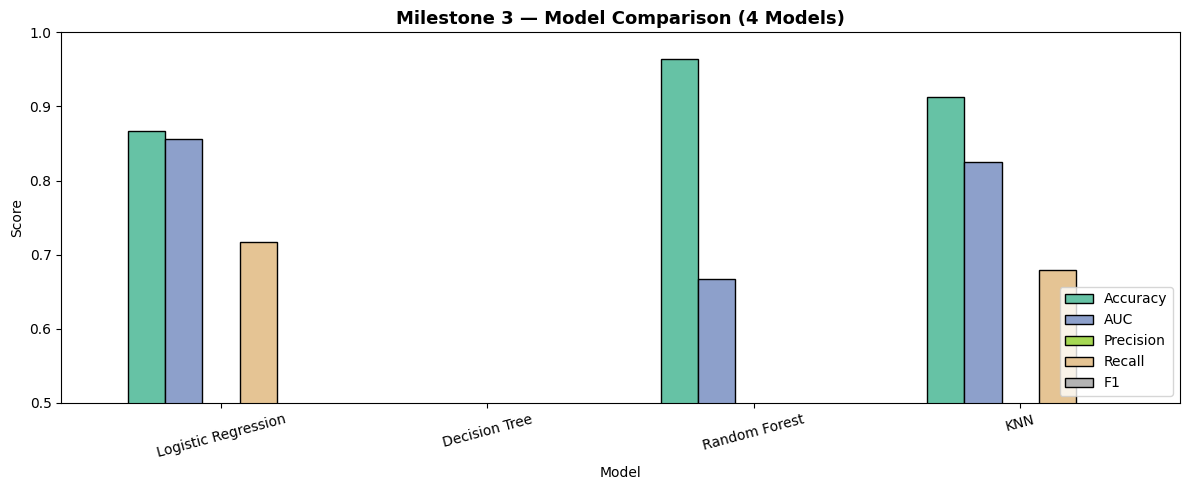

In [11]:
metrics = ['Accuracy','AUC','Precision','Recall','F1']
results_df[metrics].plot(kind='bar', figsize=(12,5), edgecolor='black',
                         colormap='Set2', width=0.7)
plt.title('Milestone 3 — Model Comparison (4 Models)', fontsize=13, fontweight='bold')
plt.ylabel('Score'); plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

### Confusion Matrices

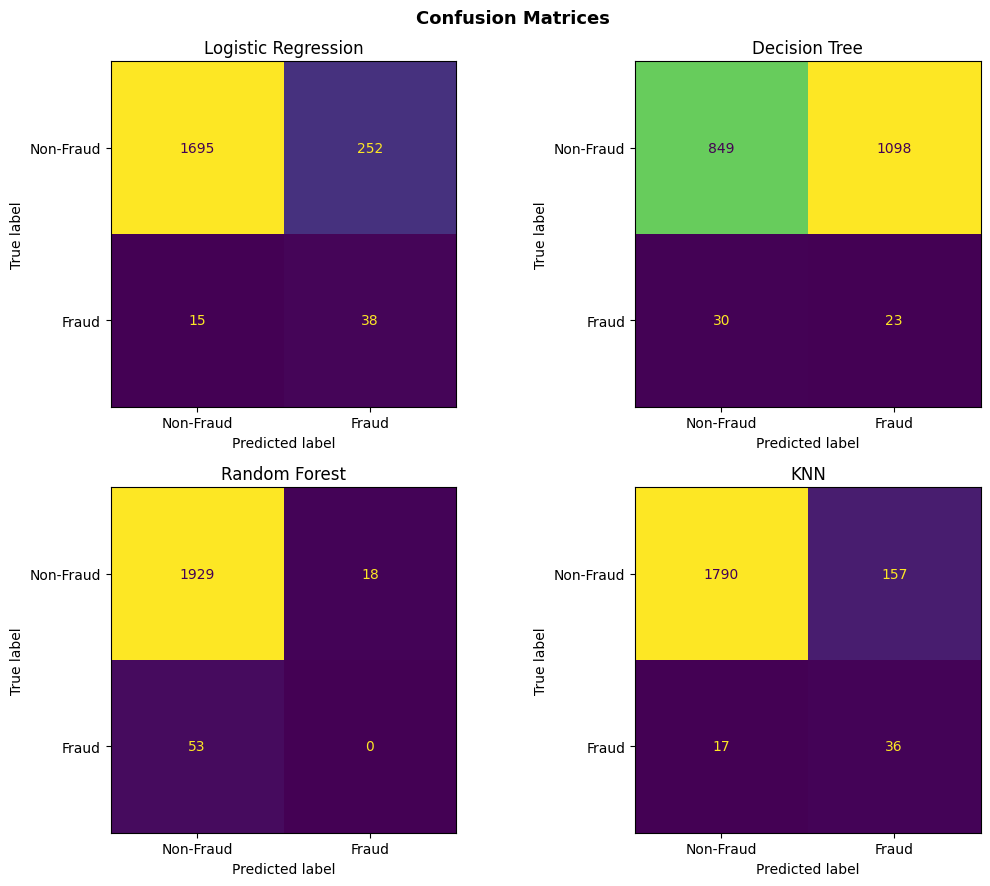

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11,9))
models_list = [('Logistic Regression', lr),
               ('Decision Tree',       dt),
               ('Random Forest',       rf),
               ('KNN',                knn)]
for ax, (name, mdl) in zip(axes.flatten(), models_list):
    Xte = X_test_sc if name in ('Logistic Regression','KNN') else X_test_sc
    pred = mdl.predict(Xte)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=['Non-Fraud','Fraud']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

✅ **Milestone 3 complete.** 4 preliminary models evaluated.

| Metric focus | Why it matters for fraud |
|---|---|
| **AUC** | Separates fraud from non-fraud across all thresholds |
| **Recall** | Catches actual fraud (minimizes false negatives) |
| **F1** | Balances Precision and Recall on imbalanced data |

→ Proceed to Milestone 4 for 4 additional models + tuning.